In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [81]:
df = pd.read_csv("P653_pronostico_dataset.csv", sep=';')

In [82]:
df.head()

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,4,78.346286,109.154591,90.713220,92.511770,retinopathy


**Basic Data Analysis**

In [83]:
df.shape

(6000, 6)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            6000 non-null   int64  
 1   age           6000 non-null   float64
 2   systolic_bp   6000 non-null   float64
 3   diastolic_bp  6000 non-null   float64
 4   cholesterol   6000 non-null   float64
 5   prognosis     6000 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 281.4+ KB


In [85]:
df.describe()

,ID,age,systolic_bp,diastolic_bp,cholesterol
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2999.500000,60.464121,100.694822,90.505547,100.628255
std,1732.195139,8.564392,10.669267,9.648200,10.433915
min,0.000000,35.164761,69.675429,62.807105,69.967453
25%,1499.750000,54.371941,93.267420,83.641788,93.202373
50%,2999.500000,59.831159,100.119926,89.912429,100.060637
75%,4499.250000,65.809652,107.439501,96.682405,107.250829
max,5999.000000,103.279497,151.699660,133.456382,148.233544


In [86]:
df.isnull().sum()

ID              0
age             0
systolic_bp     0
diastolic_bp    0
cholesterol     0
prognosis       0
dtype: int64

In [87]:
df.duplicated().sum()

0

**Exploratory Data Analysis (EDA)**

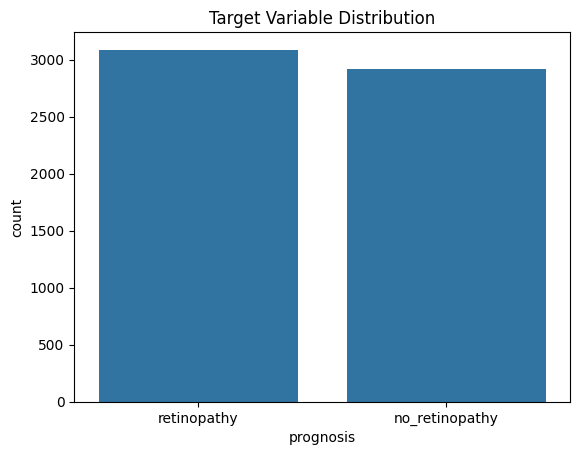

In [88]:
#Target Variable Distribution
sns.countplot(x='prognosis', data=df)
plt.title("Target Variable Distribution")
plt.show()

**Univariate Analysis (Distribution of Numerical Variables)**

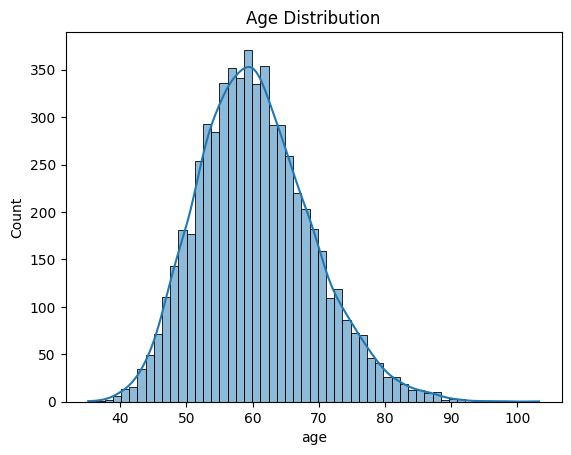

In [89]:
#Age Distribution
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()


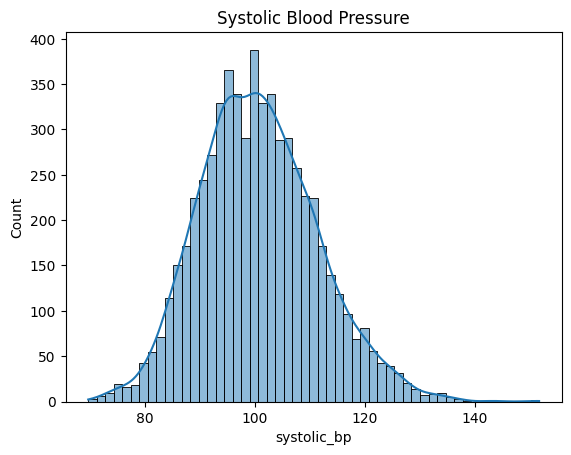

In [90]:
#Systolic BP
sns.histplot(df['systolic_bp'], kde=True)
plt.title("Systolic Blood Pressure")
plt.show()

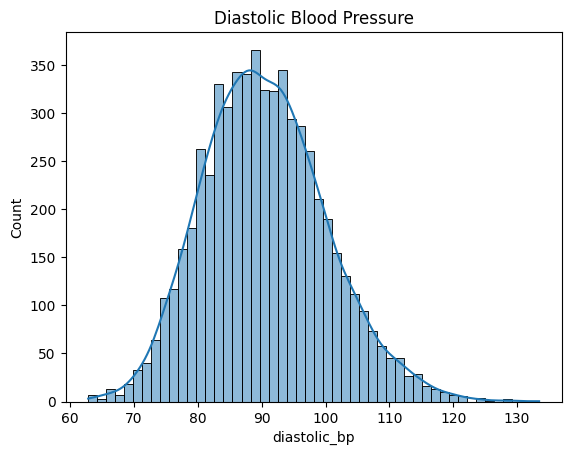

In [91]:
#Diastolic BP
sns.histplot(df['diastolic_bp'], kde=True)
plt.title("Diastolic Blood Pressure")
plt.show()

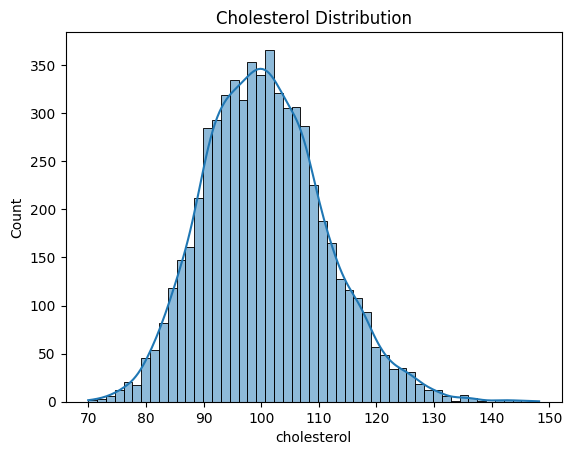

In [92]:
#Cholesterol
sns.histplot(df['cholesterol'], kde=True)
plt.title("Cholesterol Distribution")
plt.show()

**Outlier Detection Using Boxplot**

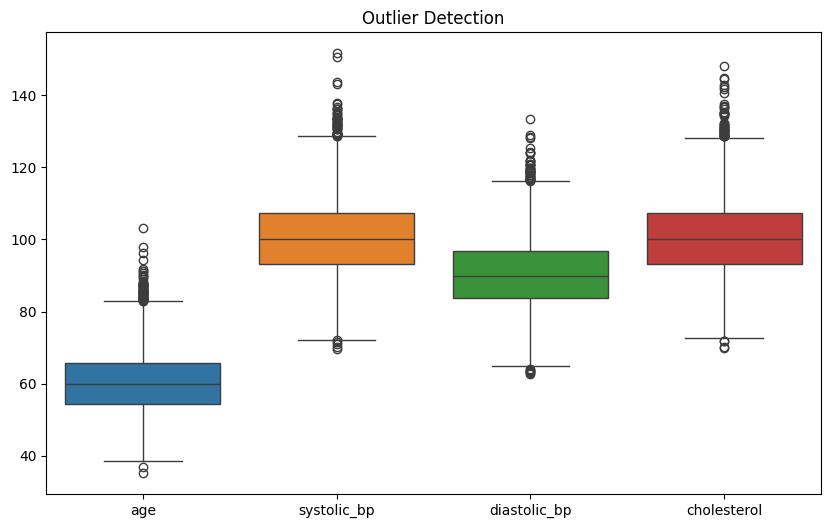

In [93]:

plt.figure(figsize=(10,6))
sns.boxplot(data=df[['age','systolic_bp','diastolic_bp','cholesterol']])
plt.title("Outlier Detection")
plt.show()


**Bivariate Analysis (Feature vs Target)**

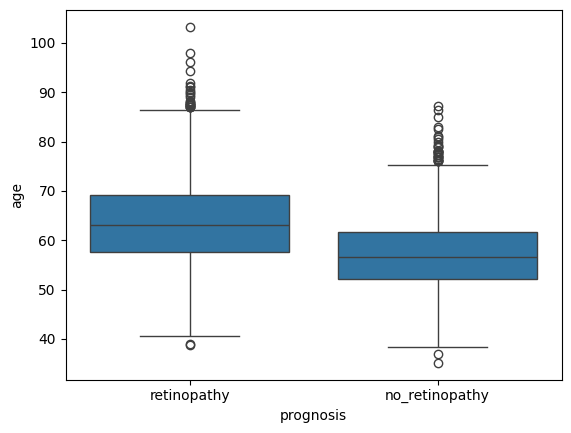

In [94]:
#Age vs Prognosis

sns.boxplot(x='prognosis', y='age', data=df)
plt.show()

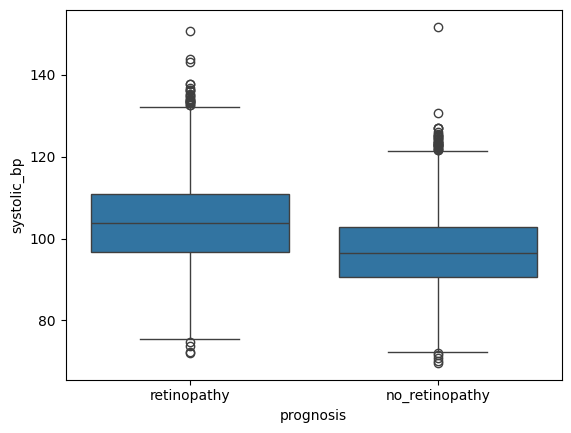

In [95]:
#Systolic BP vs Prognosis

sns.boxplot(x='prognosis', y='systolic_bp', data=df)
plt.show()

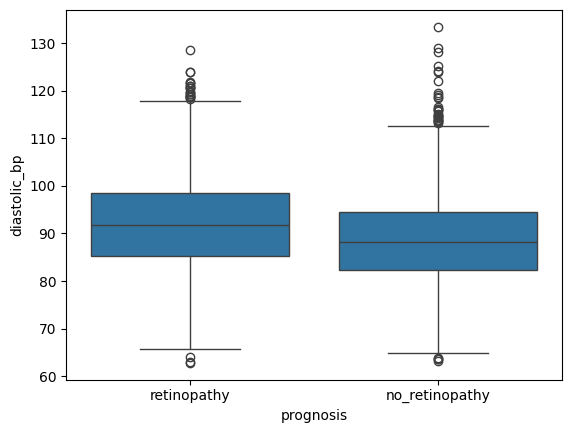

In [96]:
#Diastolic BP vs Prognosis

sns.boxplot(x='prognosis', y='diastolic_bp', data=df)
plt.show()

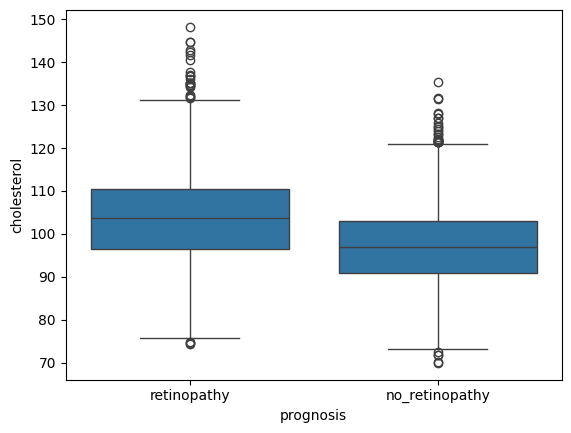

In [97]:
#Cholesterol vs Prognosis

sns.boxplot(x='prognosis', y='cholesterol', data=df)
plt.show()

**Correlation Matrix**

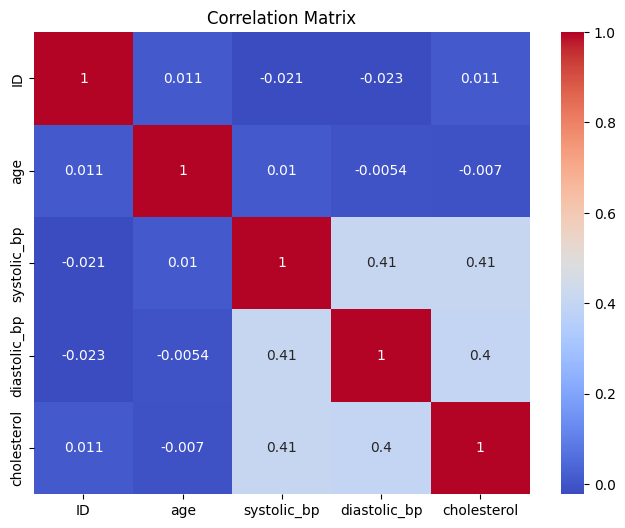

In [98]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('prognosis', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Feature Engineering**

In [99]:
# Select features and target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Yy=df["prognosis"]
y = le.fit_transform(Y)
features = ['age', 'systolic_bp', 'diastolic_bp', 'cholesterol']

X = df[features]




In [100]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 4800
Test size: 1200


In [101]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [102]:
df.shape

(6000, 6)

> We performed EDA to understand the dataset, check data distribution, and identify any missing values or issues in the data.
> Then, feature engineering and preprocessing were applied by selecting relevant features and scaling the data, preparing it for the next step of model building.


Train Accuracy: 0.74
Test Accuracy: 0.77
[[457 126]
 [153 464]]
ROC AUC: 0.84
              precision    recall  f1-score   support

           0       0.75      0.78      0.77       583
           1       0.79      0.75      0.77       617

    accuracy                           0.77      1200
   macro avg       0.77      0.77      0.77      1200
weighted avg       0.77      0.77      0.77      1200

CV AUC : 0.8180 (5-fold)


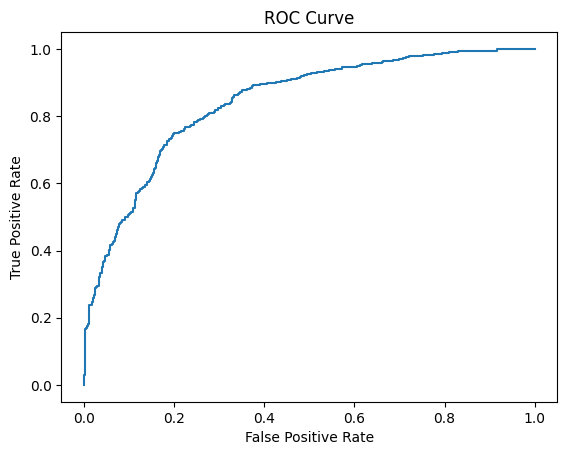

In [120]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)


# Step 1: fit the model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Step 2: Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Step 3: accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", np.round(train_accuracy,2))
print("Test Accuracy:", np.round(test_accuracy,2))

# Step 4:confusion matrics
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Step 5: roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", np.round(roc_auc,2))

# Step 5:# Step 5: classification report

print(classification_report(y_test, y_test_pred))

# Step 5: roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Cross Validation (5 fold)
# Cross Validation (5 fold)
cv = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()

print(f"CV AUC : {cv:.4f} (5-fold)")
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

Train Accuracy: 0.75
Test Accuracy: 0.75
[[420 163]
 [133 484]]
ROC AUC: 0.83
              precision    recall  f1-score   support

           0       0.76      0.72      0.74       583
           1       0.75      0.78      0.77       617

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200

CV AUC : 0.8115 (5-fold)


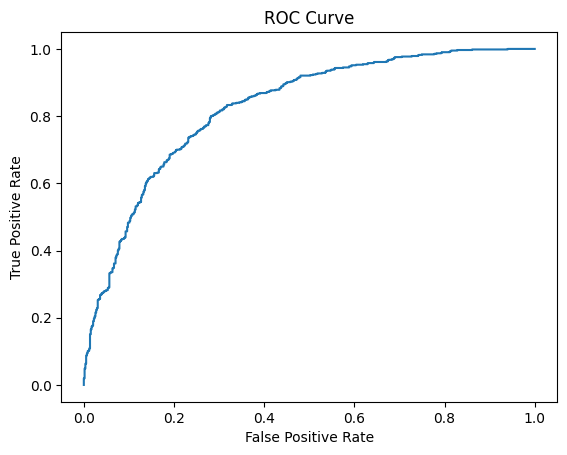

In [114]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

# Create model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_features=0.7,
    max_depth=4,
    max_samples=24
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", np.round(train_accuracy,2))
print("Test Accuracy:", np.round(test_accuracy,2))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# ROC AUC
y_prob = rf_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", np.round(roc_auc,2))

# Classification Report
print(classification_report(y_test, y_test_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Cross Validation (5 fold)
cv = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc').mean()
print(f"CV AUC : {cv:.4f} (5-fold)")

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

Train Accuracy: 0.75
Test Accuracy: 0.73
[[451 132]
 [195 422]]
ROC AUC: 0.81
              precision    recall  f1-score   support

           0       0.70      0.77      0.73       583
           1       0.76      0.68      0.72       617

    accuracy                           0.73      1200
   macro avg       0.73      0.73      0.73      1200
weighted avg       0.73      0.73      0.73      1200

  CV AUC   : 0.8030 (5-fold)


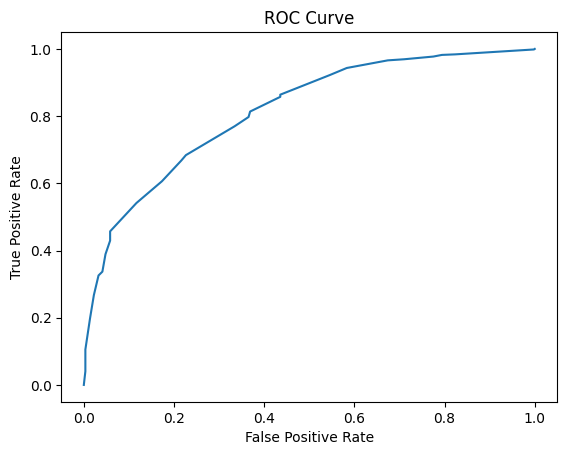

In [119]:
# Create model
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

dt_model = DecisionTreeClassifier(criterion="entropy",max_depth=5,min_samples_split=5,
    min_samples_leaf=5, random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", np.round(train_accuracy,2))
print("Test Accuracy:", np.round(test_accuracy,2))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# ROC AUC
y_prob = dt_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", np.round(roc_auc,2))

# Classification Report
print(classification_report(y_test, y_test_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Cross Validation (5 fold)
cv   = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='roc_auc').mean()


plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
print(f"  CV AUC   : {cv:.4f} (5-fold)")
plt.title("ROC Curve")
plt.show()



Train Accuracy: 0.78
Test Accuracy: 0.75
[[434 149]
 [149 468]]
ROC AUC: 0.84
              precision    recall  f1-score   support

           0       0.74      0.74      0.74       583
           1       0.76      0.76      0.76       617

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200

CV AUC : 0.8184 (5-fold)


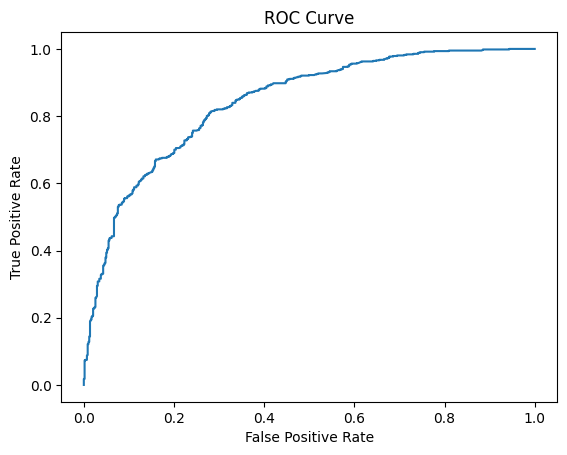

In [117]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

# Create model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train model
gb_model.fit(X_train, y_train)

# Predictions
y_train_pred = gb_model.predict(X_train)
y_test_pred = gb_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", np.round(train_accuracy,2))
print("Test Accuracy:", np.round(test_accuracy,2))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# ROC AUC
y_prob = gb_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", np.round(roc_auc,2))

# Classification Report
print(classification_report(y_test, y_test_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Cross Validation (5 fold)
cv = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='roc_auc').mean()
print(f"CV AUC : {cv:.4f} (5-fold)")

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

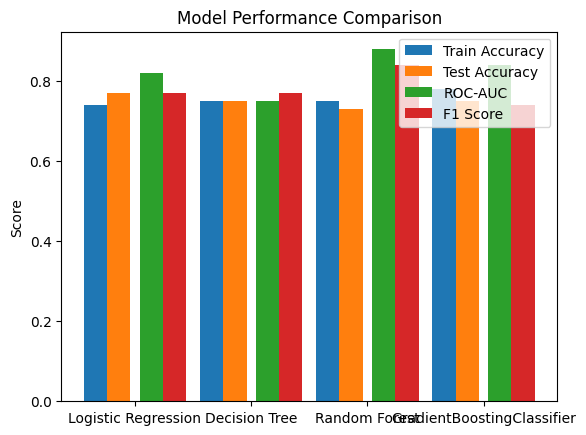

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'GradientBoostingClassifier']

# Replace these values with your results
train_acc = [0.74, 0.75, 0.75, 0.78]
test_acc = [0.77, 0.75, 0.73, 0.75]
roc_auc = [0.82, 0.75, 0.88, 0.84]
f1_scores = [0.77, 0.77, 0.84,0.74]

x = np.arange(len(models))
width = 0.2

plt.figure()

plt.bar(x - 1.7*width, train_acc, width, label='Train Accuracy')
plt.bar(x - 0.7*width, test_acc, width, label='Test Accuracy')
plt.bar(x + 0.7*width, roc_auc, width, label='ROC-AUC')
plt.bar(x + 1.7*width, f1_scores, width, label='F1 Score')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()